In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors


In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()
DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [6]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

**Nombre d'oeuvres par thème / Nombre de thèmes par oeuvre**

In [26]:

themes_per_work = pd.Series(matrix_themes.sum(axis=1), name=("Statistique des thèmes (par oeuvre)")).to_frame()
twd = themes_per_work.describe().round(2)
# => mean = moyenne du nombre de thèmes par oeuvre

works_per_theme = pd.Series(matrix_themes.sum(axis=0), name=("Statistique des oeuvres (par thème)")).to_frame()
wtd = works_per_theme.describe().round(2)
# => mean = moyenne du nombre des oeuvres par thème

result = twd.join(wtd)
result

,Statistique des thèmes (par oeuvre),Statistique des oeuvres (par thème)
count,173.00,65.00
mean,3.61,9.60
std,1.83,9.05
min,1.00,1.00
25%,2.00,5.00
50%,3.00,7.00
75%,5.00,10.00
max,10.00,57.00


**Nombre d'oeuvres contenant un thème donné**

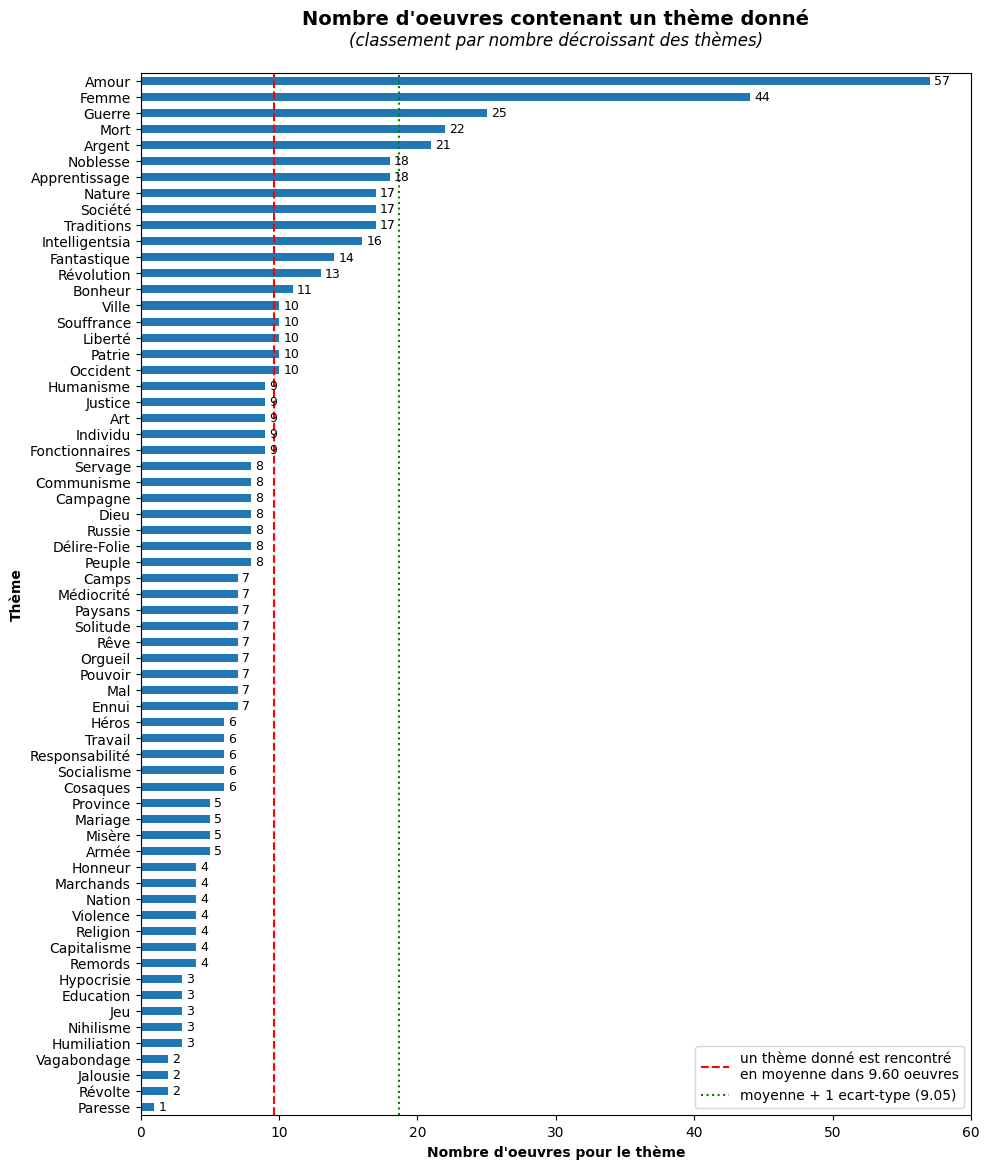

In [27]:
theme_counts = matrix_themes.sum().sort_values(ascending=False)

wtm = works_per_theme.mean().tolist()[0]
wts = works_per_theme.std().tolist()[0]

fig, ax = plt.subplots(figsize=(10, 12))

ax = theme_counts.sort_values().plot(kind="barh")

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,       # distance au-dessus de la barre (en points typographiques)
        fontsize=9,      # taille du texte
        fmt='{:,.0f}'    # éventuellement séparateur de milliers
    )

# NOTE :
# padding=2 → très proche
# padding=3–5 → généralement idéal
# padding=8+ → si les barres sont très hautes ou le graphique dense

ax.axvline(
    wtm,
    linestyle="dashed",
    color="red",
    label="un thème donné est rencontré \n"
          f"en moyenne dans {wtm:.2f} oeuvres"
)

ax.axvline(
    wtm+wts,
    linestyle=":",
    color="green",
    label=f"moyenne + 1 ecart-type ({wts:.2f})"
)

ax.set_xlabel("Nombre d'oeuvres pour le thème", fontweight="bold")
ax.set_xlim(0, 60)
ax.set_xticks(list(range(0, 70, 10)))
ax.tick_params(axis="x", labelrotation=0)

ax.set_ylabel("Thème", fontweight="bold")

ax.legend(loc="best")

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Nombre d'oeuvres contenant un thème donné", y1=35,
    t2="(classement par nombre décroissant des thèmes)", y2=20,
    t3=" ", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_par_thème_donné.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Nombre d'oeuvres contenant un thème donné (thèmes les plus fréquents)**

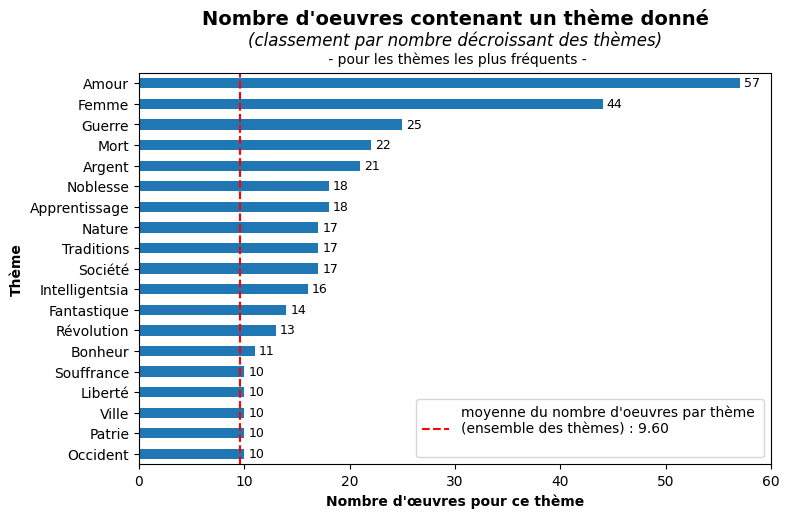

In [28]:
theme_counts = matrix_themes.sum().sort_values(ascending=False)
top = theme_counts.head(19)  
wtm = np.mean(works_per_theme)

fig, ax = plt.subplots(figsize=(8, 5))

ax = top.sort_values().plot(kind="barh")

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,       # distance au-dessus de la barre (en points typographiques)
        fontsize=9,      # taille du texte
        fmt='{:,.0f}'    # éventuellement séparateur de milliers
    )

# NOTE :
# padding=2 → très proche
# padding=3–5 → généralement idéal
# padding=8+ → si les barres sont très hautes ou le graphique dense

ax.axvline(
    wtm,
    linestyle="dashed",
    color="red",
    label="moyenne du nombre d'oeuvres par thème \n"
          f"(ensemble des thèmes) : {wtm:.2f}\n"
)

ax.set_xlabel("Nombre d'œuvres pour ce thème", fontweight="bold")
ax.set_xticks(list(range(0, 70, 10)))
ax.tick_params(axis="x", labelrotation=0)
ax.set_ylabel("Thème", fontweight="bold")

ax.legend()

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Nombre d'oeuvres contenant un thème donné", y1=35,
    t2="(classement par nombre décroissant des thèmes)", y2=20,
    t3=" - pour les thèmes les plus fréquents -", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_par_thème_donné_20_plus_fréquents.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Nombre d'oeuvres par nombre de thèmes**

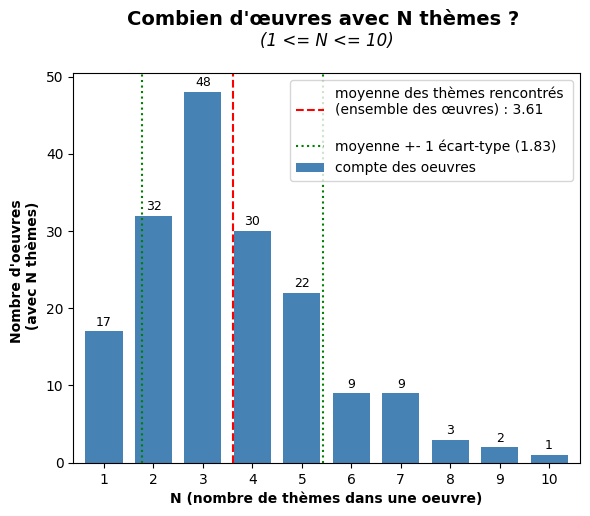

In [29]:
# themes_per_work : statistique du nombre de thèmes par oeuvre
# .iloc[:, 0] : colonne du nombre de thèmes par oeuvre
# .value_counts() : nombre de fois où chaque nombre de thèmes apparaît
# .sort_index() : on classe les nombres de fois du min au max

counts = (
    themes_per_work.iloc[:, 0]
    .value_counts()
    .sort_index()
)
counts.name = "compte des oeuvres"

twm = themes_per_work.mean().tolist()[0]
tws = themes_per_work.std().tolist()[0]

fig, ax = plt.subplots(figsize=(6, 5))

ax = counts.plot(
    kind="bar", 
    width=0.75, 
    color="steelblue",
    zorder=1
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=2,
        fontsize=9,
        fmt="{:,.0f}"
    )

# Dans le graphique, les nombres de thèmes affichés N = 1, 2, 3, 4, 5 ...
# sont traitées par Matplotlib comme des positions discrètes 
# que Matplotlib convertit automatiquement en : MPL = 0, 1, 2, 3, 4, 5 ...
# MPL = N-1 => donc pour tvm = 3.6069..., il faut que Matplotlib interprète : tvm-1

ax.axvline(
    twm-1,
    linestyle="dashed",
    color="red",
    label="moyenne des thèmes rencontrés \n"
          f"(ensemble des œuvres) : {twm:.2f}\n"
)

ax.axvline(
    twm+tws-1,
    linestyle=":",
    color="green",
    label=f"moyenne +- 1 écart-type ({tws:.2f})"
)

ax.axvline(
    twm-tws-1,
    linestyle=":",
    color="green",
#    label=f"moyenne +- 1 écart-type ({tws:.2f})",
    zorder=3
)

ax.set_xlabel("N (nombre de thèmes dans une oeuvre)", fontweight="bold")
ax.set_ylabel("Nombre d'oeuvres \n (avec N thèmes)", fontweight="bold")
ax.set_xticks(
    ticks=range(len(counts)),
    labels=counts.index,
    rotation=0
)

ax.legend()

fig.tight_layout(rect=[0, 0, 1, 0.93])

titres(
    fig,
    ax,
    t1="Combien d'œuvres avec N thèmes ? ", y1=35,
    t2="(1 <= N <= 10)", y2=20,
    t3=" ", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_par_nombre_thèmes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


**importance des thèmes par nuage de mots pondéré**

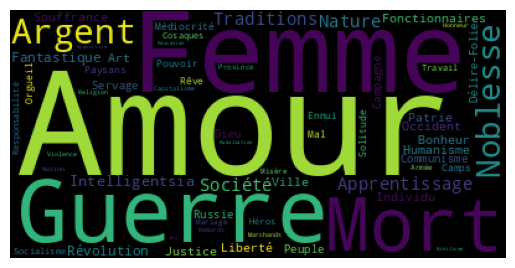

In [11]:
from wordcloud import WordCloud

theme_counts = matrix_themes.sum().sort_values(ascending=False)

wc = WordCloud()

wc.generate_from_frequencies(theme_counts)

plt.imshow(wc)

plt.axis("off")

plt.savefig(
    IMG_DIR / "thèmes_nuage_mots_pondéré.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()